<!-- SPDX-FileCopyrightText: 2026 Orbital Research Cluster for Celestial Applications (ORCCA) Lab, University of Colorado at Boulder -->
<!-- SPDX-License-Identifier: ISC -->
# Propagator Comparisons (IAS15 & DOP853)
---
Last revised by Z. Ellis on 2026 MAR 30

## Objectives
This tutorial will demonstrate the usage of the two different integrators supported within Scarabaeus' Propagator class, DOP853 and IAS15, across increasingly complex dynamics configurations. The configurations are:

1) Keplerian orbit
2) Keplerian orbit + third body perturbations
3) Keplerian orbit + third body perturbations + cannonball solar radiation pressure model
4) Keplerian orbit + third body perturbations + N-plate solar radiation pressure model
5) Keplerian orbit + third body perturbations + N-plate solar radiation pressure model + spherical harmonics gravity

The differences are highlighted by examining an inclined, elliptical geocentric orbit and noting where and why one integrator calculates different results than the other.
Performance metrics like computational efficiency are also examined.

## Imports and Set Up

Here we'll import the necessary libraries, define units and frames, and load a metakernel for SPICE time conversions.

In [1]:
import scarabaeus as scb

import os, time
import pyrootutils

import numpy as np
import matplotlib.pyplot as plt

os.chdir(pyrootutils.setup_root(os.getcwd(), indicator = 'pyproject.toml', pythonpath = True))

## units, frames, kernels
kg, km, sec = scb.Units.get_units(['kg', 'km', 'sec'])
J2000 = scb.Frame('J2000')

import supplementary as supp
data = supp.load_data()
scb.SpiceManager.clear_kernels()
scb.SpiceManager.load_kernel_from_mkfile(data.mk.path)

SCB tutorial data up to date.


## Define Propagation Parameters

Next, we'll create an object to represent Earth, the body we'll be orbiting in this tutorial, and its spherical harmonics information `sh_info`. We also need to create an orbiting spacecraft `sc` and an N-plate model for it.

We'll also define the time interval we want to propagate over and a few orbital elements.

In [2]:
## earth and spacecraft
earth   = scb.CelestialBody.from_constants("EARTH")
sh_info = {'order'    : 3,
           'cs_file'  : 'data/dynamic_setup/sph_coefficients/Earth_100.json',
           'body'     : scb.EARTH,
           'norm_flag': True}

n_plate = scb.nPlateModel('data/dynamic_setup/nplate_coefficients/VandV_case5a_nPlate_config.json')
sc      = scb.Spacecraft(name      = 'ORCCA_SC',
                         spice_id  = -1000,
                         tot_mass  = scb.ArrayWUnits(2000, kg),
                         area      = scb.ArrayWUnits(1e-06, km**2),
                         ref_coeff = scb.ArrayWUnits(1.5, None),
                         n_plate_model     = n_plate,
                         attitudeMode      = 'nadir_pointing_to_sun',
                         nadirPointingAxis = np.array([-1, 0, 0]))

## orbital parameters
t0     = scb.SpiceManager.cal2et('2026 JAN 01 00:00:00.000')
tf     = scb.SpiceManager.cal2et('2026 JAN 01 10:00:00.000')    # 10 hours
epochs = scb.EpochArray(np.arange(t0, tf, 500), 'TDB')

# semi major axis, ecccentricity, inclination, gravitational parameter
a, e, i, mu = 25000, 0.5, np.deg2rad(35), earth.grav_param.values

AttributeError: module 'scarabaeus' has no attribute 'EARTH'

We want to examine how our integrators differ from one another, and the point that we'll likely see the largest difference will be at periapsis where the spacecraft is moving fastest. In order to see this better, we want to examine a few different trajectories with initial conditions at different points in the orbit. We'll create a function `state_at_nu` which will find the state corresponding to a given true anomaly nu so we can test these different initial true anomalies when we start propagating.

In [3]:
def state_at_nu(nu):
    """
        Function to calculate state at given true anomaly nu.
    """
    # perifocal position and velocity
    h  = np.sqrt(mu*a*(1 - e**2))        # angular momentum 
    r  = h**2 / (mu*(1 + e*np.cos(nu)))
    r0 = np.array([r*np.cos(nu), r*np.sin(nu), 0])
    v0 = np.array([-(mu/h)*np.sin(nu), (mu/h) * (e + np.cos(nu)), 0])

    # rotate to intertial intertial
    peri_to_n = np.array([[1,         0,          0],
                          [0, np.cos(i), -np.sin(i)],
                          [0, np.sin(i), np.cos(i)]])
    r0 = (peri_to_n @ r0.reshape((3, 1))).flatten()
    v0 = (peri_to_n @ v0.reshape((3, 1))).flatten()

    # convert to AWF and return
    pos0 = scb.ArrayWFrame(r0, km    , J2000)
    vel0 = scb.ArrayWFrame(v0, km/sec, J2000)

    return (pos0, vel0)

## Set up Propagation (and Plotting)
Since we want to look at a few different propagation configurations, we'll define another function that can:
1) propagate any arbitrary dynamics configuration
2) plot the resulting propagation

We'll do this under `prop_and_plot_fm`, which will first initialize a figure, then initialize four different initial conditions at different true anomalies using `state_at_nu`. For each true anomaly, it will then propagate the initial conditions using both the DOP853 and the IAS15 integrator and compare their differences as percents for each state component. We'll also return the average percent differences so that we can look at how each set of dynamics changes the results.

In [4]:
## plotting
def prop_and_plot_fm(model, title):
    """
        Function to propagate the given dynamics using both DOP853 and IAS15 
        integrators. Plots the results and returns the average percent errors 
        for each state component.

        Also returns average computation time for both integrators.
    """
    # initialize plot
    fig, axes = plt.subplot_mosaic([['o', 'o', '$X$', '$Y$', '$Z$'],
                                    ['o', 'o', '$\dot{X}$', '$\dot{Y}$', '$\dot{Z}$']],
                                    per_subplot_kw = {'o' : {'projection' : '3d'}},
                                    constrained_layout = True, figsize = (17, 9))
    
    # examine four different initial true anomaly cases
    nus = [-90, 0, 90, 180] # approaching peri, at peri, approaching apo, at apo

    # save computation time for each propagator and differences between them
    tot_avg_pos_err, tot_avg_vel_err, times, traj_errs = [], [], [], []
    dop_time, ias_time = [], []
    for j, nu in enumerate(nus):
        # get state that corresponds to this case's true anomaly
        pos0, vel0 = state_at_nu(np.rad2deg(nu))
        state = [("position", 3, "estimated", "dynamic", sc, pos0),
                 ("velocity", 3, "estimated", "dynamic", sc, vel0)]
        state_vector = scb.StateArray(epoch  = epochs[0],
                                      origin = earth,
                                      state  = scb.StateDefinition.from_components(state))
        
        # propagate with DOP853
        dop_start = time.time()
        prop_dop = scb.Propagator(primary_body  = sc,
                                  state_vector  = state_vector,
                                  tspan         = epochs,
                                  integrator    = 'DOP853',
                                  force_models  = model,
                                  propagate_STM = False)
        prop_dop.propagate()
        dop_time.append(time.time() - dop_start)
        ys_dop = prop_dop.ys

        # and IAS15
        ias_start = time.time()
        prop_ias  = scb.Propagator(primary_body  = sc,
                                   state_vector  = state_vector,
                                   tspan         = epochs,
                                   integrator    = 'IAS15',
                                   force_models  = model,
                                   propagate_STM = False)
        prop_ias.propagate()
        ias_time.append(time.time() - ias_start)
        ts_ias = prop_ias.times.times.values
        ys_ias = prop_ias.ys
        times.append(ts_ias)

        ## plot 3d orbit
        # IAS15
        if j == 0:  # only need legend labels for one
            axes['o'].plot(ys_ias[:, 0], ys_ias[:, 1], ys_ias[:, 2], 
                           'b', label = 'IAS15')
            axes['o'].plot(ys_ias[0, 0], ys_ias[0, 1], ys_ias[0, 2],
                           'go', label = 'IAS15 $t_0$')
            axes['o'].plot(ys_ias[-1, 0], ys_ias[-1, 1], ys_ias[-1, 2],
                           'rs', label = 'IAS15 $t_f$')
        else:
            axes['o'].plot(ys_ias[:, 0], ys_ias[:, 1], ys_ias[:, 2], 
                           linewidth = 1.4)
            axes['o'].plot(ys_ias[0, 0], ys_ias[0, 1], ys_ias[0, 2], 'go')
            axes['o'].plot(ys_ias[-1, 0], ys_ias[-1, 1], ys_ias[-1, 2], 'rs')
        
        # note which true anomaly only for IAS15
        match nu:
            case -90: offset = (0, 1000, 0, 1000)
            case 0  : offset = (1000, -1000, 1000, 1000)
            case 90 : offset = (0, 1000, 0, 2000)
            case 180: offset = (0, -2000, 0, 1000)
        axes['o'].text(ys_ias[0, 0]+offset[0], ys_ias[0, 1], ys_ias[0, 2]+offset[1],
                       f'\u03bd$_0 =$ {nu}$^\circ$')
        axes['o'].text(ys_ias[-1, 0]+offset[2], ys_ias[-1, 1], ys_ias[-1, 2]+offset[3],
                       f'\u03bd$_0 =$ {nu}$^\circ$')

        # DOP853
        if j == 0:  # only need legend labels for one
            axes['o'].plot(ys_dop[:, 0], ys_dop[:, 1], ys_dop[:, 2],
                           'k--', alpha = 0.6, label = 'DOP853')
            axes['o'].plot(ys_dop[0, 0], ys_dop[0, 1], ys_dop[0, 2],
                           'm.', label = 'DOP853 $t_0$')
            axes['o'].plot(ys_dop[-1, 0], ys_dop[-1, 1], ys_dop[-1, 2],
                           'b+', label = 'DOP853 $t_f$')
        else:
            axes['o'].plot(ys_dop[:, 0], ys_dop[:, 1], ys_dop[:, 2],
                           '--', linewidth = 0.9)
            axes['o'].plot(ys_dop[0, 0], ys_dop[0, 1], ys_dop[0, 2], 'm.')
            axes['o'].plot(ys_dop[-1, 0], ys_dop[-1, 1], ys_dop[-1, 2], 'b+')

        # percent errors
        err = np.nan_to_num(abs((ys_ias[:] - ys_dop[:, 0:6]) / ys_ias)*100, nan = 0)
        traj_errs.append(err)

        # calculate average percent errors and save for this initial true anomaly
        avg_pos_err = np.mean(err[:, 0:3])
        avg_vel_err = np.mean(err[:, 3:6])
        tot_avg_pos_err.append(avg_pos_err), tot_avg_vel_err.append(avg_vel_err)
    
    # primary body
    axes['o'].plot(0, 0, 0, 'ko')

    # formatting
    axes['o'].set_title(f'IAS15 Avg Computation Time = {np.mean(ias_time):.3f} sec\n'
                        f'DOP853 Avg Computation Time = {np.mean(dop_time):.3f} sec')
    axes['o'].legend(bbox_to_anchor = (0.5, -0.15), loc = 'lower center', ncols = 2)
    axes['o'].set_aspect('equal'), axes['o'].view_init(elev = 33, azim = -60)

    ## plot percent errors for each initial true case
    # plot values with smaller average error in front of ones with larger
    zorder_inds = sorted(range(len(traj_errs)), key = lambda err: np.mean(err), reverse = True)
    traj_errs   = [traj_errs[j] for j in zorder_inds]
    nus         = [nus[j] for j in zorder_inds]
    for t, traj_err, nu in zip(times, traj_errs, nus):
        for j, ax in enumerate(axes):
            if ax != 'o':
                axes[ax].plot((t - t0)/3600, traj_err[:, j - 1], '-o', markersize = 3,
                              label = f'\u03bd$_0 =$ {nu}$^\circ$')
                axes[ax].set_xlabel('Time [hrs]')
                axes[ax].set_ylabel('IAS15 - DOP853 % Difference')
                axes[ax].set_title(ax + f'\n Mean Difference: {np.mean(err[:, j - 1]):.4e} %')
                axes[ax].grid(), axes[ax].legend()

    # finalize plot and return average valeus
    fig.suptitle(title)
    plt.show()
    return (np.mean(tot_avg_pos_err), np.mean(tot_avg_vel_err))

## Dynamics Models and Analysis
Now that we have a function that can propagate and plot any dynamics we give it, we need to define those dynamics. As a reminder, these are the five dynamics cases we will examine:

1) Keplerian orbit
2) Keplerian orbit + third body perturbations
3) Keplerian orbit + third body perturbations + cannonball solar radiation pressure model
4) Keplerian orbit + third body perturbations + N-plate solar radiation pressure model
5) Keplerian orbit + third body perturbations + N-plate solar radiation pressure model + spherical harmonics gravity

We'll define each of these cases using `ForceModelTranslation` and then feed it to `prop_and_plot_fm` to compare the two propagators. We're also saving the percent differences computed by `prop_and_plot_fm` to compare the two integrators for every force model later.

In [5]:
## create and plot increasingly complex dynamics
# two body orbit
twobp = scb.ForceModelTranslation(primary_body = sc)
twobp_errs = prop_and_plot_fm(twobp, f'a = {a} km, i = {np.rad2deg(i):.2f}$^\circ$\n'
                                      'Earth Orbit')

NameError: name 'sc' is not defined

In [6]:
# same as above with third bodies added
nBP = scb.ForceModelTranslation(primary_body = sc, 
                                third_bodies = ['MERCURY', 'VENUS'])
nBP_errs = prop_and_plot_fm(nBP, f'a = {a} km, i = {np.rad2deg(i):.2f}$^\circ$\n'
                                'Earth Orbit | 3rd Bodies: Mercury & Venus')

NameError: name 'sc' is not defined

In [7]:
# all above + cannonball SRP
cannon = scb.ForceModelTranslation(primary_body   = sc,
                                    third_bodies   = ['MERCURY', 'VENUS'],
                                    cannonball_SRP = True)
cannon_errs = prop_and_plot_fm(cannon, f'a = {a} km, i = {np.rad2deg(i):.2f}$^\circ$\n'
                                        'Earth Orbit | 3rd Bodies: Mercury & Venus | Cannonball SRP')

NameError: name 'sc' is not defined

In [8]:
# same as above with N-plate SRP instead of cannonball
npl = scb.ForceModelTranslation(primary_body = sc,
                                third_bodies = ['MERCURY', 'VENUS'],
                                nplate_SRP   = True)
npl_errs = prop_and_plot_fm(npl, f'a = {a} km, i = {np.rad2deg(i):.2f}$^\circ$\n'
                                'Earth Orbit | 3rd Bodies: Mercury & Venus | N-Plate SRP')

NameError: name 'sc' is not defined

In [9]:
# all above + spherical harmonics
sph = scb.ForceModelTranslation(primary_body       = sc, 
                                third_bodies       = ['MERCURY', 'VENUS'], 
                                nplate_SRP         = True,
                                sph_harm           = True,
                                sph_harm_order     = sh_info['order'],
                                sph_harm_cs_file   = sh_info['cs_file'],
                                sph_harm_body      = sh_info['body'],
                                sph_harm_norm_flag = sh_info['norm_flag'])
sph_errs = prop_and_plot_fm(sph, f'a = {a} km, i = {np.rad2deg(i):.2f}$^\circ$\n'
                                'Earth Orbit | 3rd Bodies: Mercury & Venus | N-Plate SRP | 3rd Order SPH')

NameError: name 'sc' is not defined

Now plot the average difference between DOP853 and IAS15 for position and velocity for all force model configurations.

NameError: name 'sph_errs' is not defined

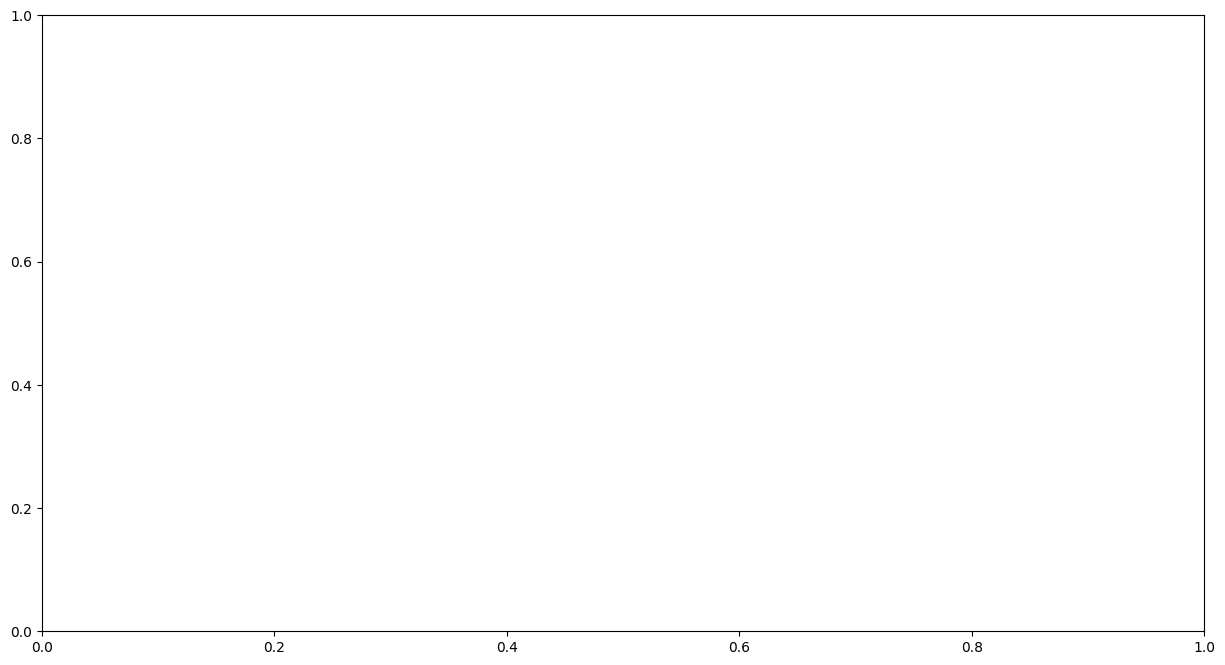

In [10]:
## plot average percent differences
# set up titles and colors
cases = ['2BP + 3rd Bodies\n& N-Plate & SPH', '2BP + 3rd Bodies\n& N-Plate', 
         '2BP + 3rd Bodies\n& Cannonball', '2BP + 3rd Bodies', '2BP']
ind, width = np.arange(len(cases)), 0.4
cmap = plt.get_cmap('tab10')
c = cmap(np.linspace(0, 1, len(cases)))

# position differences
fig_bar_pos, ax_bar_pos = plt.subplots(figsize = (15, 8))
# rust vs dop
bars = ax_bar_pos.barh(ind + width/2, [sph_errs[0], npl_errs[0], cannon_errs[0], nBP_errs[0], twobp_errs[0]], width, color = c)
ax_bar_pos.bar_label(bars, fmt='%.2e', padding=5)

ax_bar_pos.set(yticks = ind, yticklabels = cases)
ax_bar_pos.set_xlabel('Average Position Difference [%]'), ax_bar_pos.set_ylabel('Cases')
ax_bar_pos.set_xlim(0, 1.1*ax_bar_pos.get_xlim()[1])    # padding for bar labels
ax_bar_pos.set_title('Average Position Differences Between IAS15 and DOP853')

# velocity differences
fig_bar_vel, ax_bar_vel = plt.subplots(figsize = (15, 8))
# rust vs dop
bars = ax_bar_vel.barh(ind + width/2, [sph_errs[1], npl_errs[1], cannon_errs[1], nBP_errs[1], twobp_errs[1]], width, color = c)
ax_bar_vel.bar_label(bars, fmt='%.2e', padding=5)

ax_bar_vel.set(yticks = ind, yticklabels = cases)
ax_bar_vel.set_xlabel('Average Velocity Difference [%]'), ax_bar_vel.set_ylabel('Cases')
ax_bar_vel.set_xlim(0, 1.1*ax_bar_vel.get_xlim()[1])    # padding for bar labels
ax_bar_vel.set_title('Average Velocity Differences Between IAS15 and DOP853')

## Conclusion
FILL OUT